# cw_odmr_lock_in result: scan1-scan8

First runs taken after fixing the AWG CH1 issue (see `notes.md`'s SR830 section -- `*RST` was silently resetting CH1's continuous carrier off on every connection; `setup_ch1_carrier()` now re-configures it every run) -- from `D:\cw_odmr_lock_in\scan{1..8}`. These are the first valid runs showing the real dip.

Some points read as saturated (a value hit some level and stayed there for several consecutive frequency points -- an ADC/sensitivity clipping signature, not real signal, since real noise essentially never repeats bit-for-bit). `find_saturated_mask()` below flags these; they're plotted grayed out rather than dropped, so you can see where/how much of each scan is affected.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

DATA_DIR = r"D:\cw_odmr_lock_in"
RUN_NAMES = ["scan1", "scan2", "scan3", "scan4", "scan5", "scan6", "scan7", "scan8"]

runs = {}
for name in RUN_NAMES:
    run_path = f"{DATA_DIR}/{name}"
    freqs_hz = np.load(f"{run_path}/{name}_lockin_spectrum_freqs_hz.npy")
    x = np.load(f"{run_path}/{name}_lockin_spectrum_x.npy")
    y = np.load(f"{run_path}/{name}_lockin_spectrum_y.npy")
    reflected_dbm = np.load(f"{run_path}/{name}_lockin_spectrum_reflected_dbm.npy")
    freqs_ghz = freqs_hz / 1e9
    runs[name] = dict(freqs_ghz=freqs_ghz, x=x, y=y, r=np.hypot(x, y),
                       reflected_dbm=reflected_dbm)
    print(f"{name}: {len(freqs_hz)} points, "
          f"{freqs_ghz.min():.6f}-{freqs_ghz.max():.6f} GHz")

scan1: 137 points, 2.860250-2.873850 GHz
scan2: 130 points, 2.859750-2.872650 GHz
scan3: 133 points, 2.860725-2.873925 GHz
scan4: 116 points, 2.865825-2.877325 GHz
scan5: 136 points, 2.444725-2.458225 GHz
scan6: 129 points, 2.832600-2.845400 GHz
scan7: 123 points, 2.839600-2.851800 GHz
scan8: 122 points, 2.851450-2.863550 GHz


## Saturation detection

In [2]:
def find_saturated_mask(values, min_run=3):
    """
    Flag points that are part of a run of >= min_run consecutive
    (near-)identical values -- a stuck/saturated reading (ADC or
    sensitivity-range clipping), not real signal or noise: real noise
    essentially never repeats bit-for-bit for that many points in a row.
    Returns a boolean array, True where a point belongs to such a run.
    """
    values = np.asarray(values)
    n = len(values)
    mask = np.zeros(n, dtype=bool)
    if n == 0:
        return mask
    run_start = 0
    for i in range(1, n):
        if not np.isclose(values[i], values[i - 1], rtol=1e-9, atol=0):
            if i - run_start >= min_run:
                mask[run_start:i] = True
            run_start = i
    if n - run_start >= min_run:
        mask[run_start:] = True
    return mask


for name in RUN_NAMES:
    sat = find_saturated_mask(runs[name]["x"])
    runs[name]["saturated"] = sat
    print(f"{name}: {sat.sum()}/{len(sat)} points flagged saturated")

scan1: 0/137 points flagged saturated
scan2: 0/130 points flagged saturated
scan3: 0/133 points flagged saturated
scan4: 0/116 points flagged saturated
scan5: 0/136 points flagged saturated
scan6: 0/129 points flagged saturated
scan7: 0/123 points flagged saturated
scan8: 26/122 points flagged saturated


## Comparison: scan1 vs scan2 vs ... vs scan8 (saturated points grayed out)

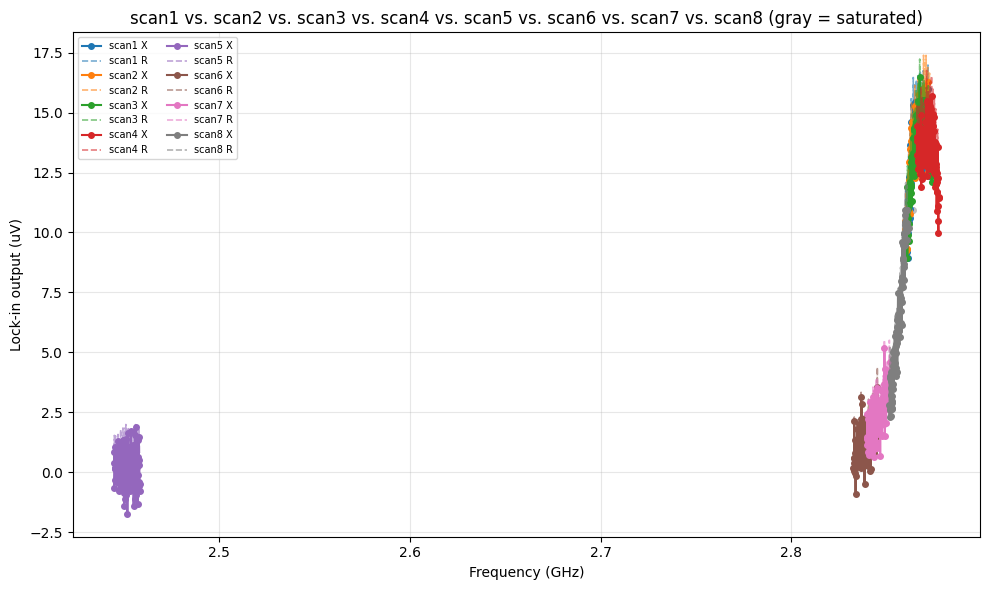

In [3]:
fig, ax = plt.subplots(figsize=(10, 6))
colors = plt.cm.tab10.colors

for i, name in enumerate(RUN_NAMES):
    d = runs[name]
    color = colors[i % len(colors)]
    sat = d["saturated"]
    freqs = d["freqs_ghz"]
    x_uv = d["x"] * 1e6
    r_uv = d["r"] * 1e6

    x_good = np.where(sat, np.nan, x_uv)
    r_good = np.where(sat, np.nan, r_uv)
    x_bad = np.where(sat, x_uv, np.nan)
    r_bad = np.where(sat, r_uv, np.nan)

    ax.plot(freqs, x_good, "o-", color=color, ms=4, label=f"{name} X")
    ax.plot(freqs, r_good, "--", color=color, lw=1.2, alpha=0.6, label=f"{name} R")
    ax.plot(freqs, x_bad, "o", color="0.75", ms=4, zorder=1)
    ax.plot(freqs, r_bad, "--", color="0.75", lw=1.2, alpha=0.6, zorder=1)

ax.set_xlabel("Frequency (GHz)")
ax.set_ylabel("Lock-in output (uV)")
ax.set_title(" vs. ".join(RUN_NAMES) + " (gray = saturated)")
ax.legend(fontsize=7, ncol=2)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [4]:
ZOOM_RUN_NAMES = [n for n in RUN_NAMES if n != "scan5"]

from scipy.optimize import curve_fit

def lorentzian_dip(f, baseline, amplitude, center, fwhm):
    return baseline - amplitude * (fwhm / 2) ** 2 / ((f - center) ** 2 + (fwhm / 2) ** 2)

## Combined fit: all scans except scan5, single Lorentzian

Pools every non-saturated point from all of `ZOOM_RUN_NAMES` into one dataset (sorted by frequency) and fits a single Lorentzian, instead of fitting each scan separately.

In [5]:
combined_freqs_mhz = np.concatenate([
    runs[name]["freqs_ghz"][~runs[name]["saturated"]] * 1e3
    for name in ZOOM_RUN_NAMES
])
combined_x_uv = np.concatenate([
    runs[name]["x"][~runs[name]["saturated"]] * 1e6
    for name in ZOOM_RUN_NAMES
])

order = np.argsort(combined_freqs_mhz)
combined_freqs_mhz = combined_freqs_mhz[order]
combined_x_uv = combined_x_uv[order]

print(f"{len(combined_freqs_mhz)} combined points, "
      f"{combined_freqs_mhz.min():.4f}-{combined_freqs_mhz.max():.4f} MHz")

baseline_guess = np.median(np.concatenate([combined_x_uv[:10], combined_x_uv[-10:]]))
dip_idx = np.argmin(combined_x_uv) if abs(combined_x_uv.min() - baseline_guess) > abs(combined_x_uv.max() - baseline_guess) \
    else np.argmax(combined_x_uv)
center_guess = combined_freqs_mhz[dip_idx]
amplitude_guess = baseline_guess - combined_x_uv[dip_idx]
span_mhz = combined_freqs_mhz.max() - combined_freqs_mhz.min()
fwhm_guess = span_mhz / 10

combined_popt, combined_pcov = curve_fit(
    lorentzian_dip, combined_freqs_mhz, combined_x_uv,
    p0=[baseline_guess, amplitude_guess, center_guess, fwhm_guess],
    maxfev=20000,
)
combined_perr = np.sqrt(np.diag(combined_pcov))
baseline_fit, amplitude_fit, center_fit, fwhm_fit = combined_popt

print(f"combined fit: baseline = {baseline_fit:.4f} +/- {combined_perr[0]:.4f} uV")
print(f"combined fit: amplitude = {amplitude_fit:.4f} +/- {combined_perr[1]:.4f} uV")
print(f"combined fit: center = {center_fit:.4f} +/- {combined_perr[2]:.4f} MHz")
print(f"combined fit: FWHM = {abs(fwhm_fit):.4f} +/- {combined_perr[3]:.4f} MHz")

864 combined points, 2832.6000-2877.3250 MHz
combined fit: baseline = -1.9442 +/- 0.1571 uV
combined fit: amplitude = -16.6479 +/- 0.1451 uV
combined fit: center = 2869.2129 +/- 0.0877 MHz
combined fit: FWHM = 27.9491 +/- 0.5351 MHz


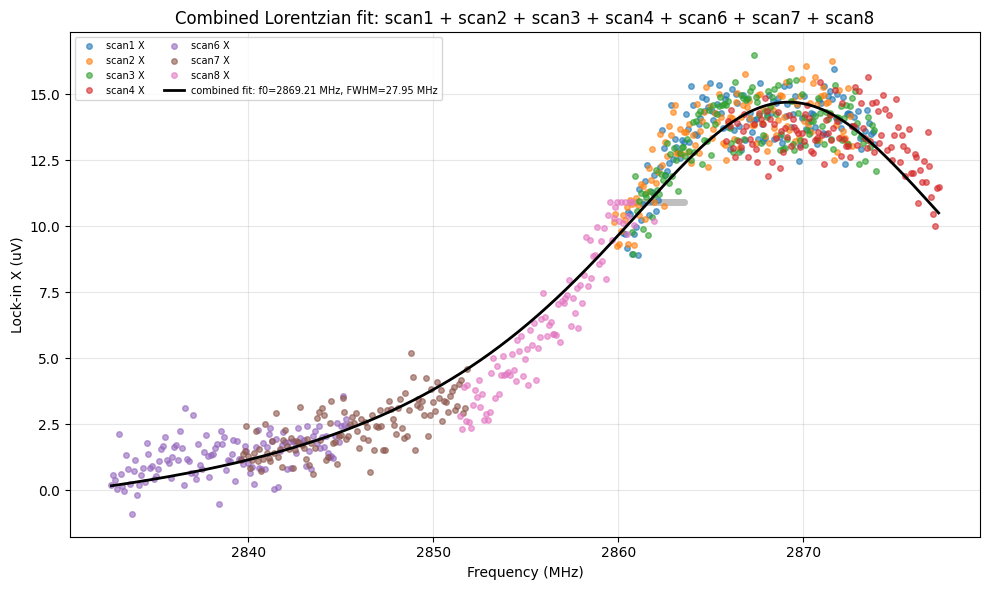

In [6]:
fig, ax = plt.subplots(figsize=(10, 6))

for i, name in enumerate(ZOOM_RUN_NAMES):
    d = runs[name]
    color = colors[i % len(colors)]
    sat = d["saturated"]
    freqs_mhz = d["freqs_ghz"] * 1e3
    x_uv = d["x"] * 1e6
    ax.plot(freqs_mhz[~sat], x_uv[~sat], "o", color=color, ms=4, alpha=0.6, label=f"{name} X")
    ax.plot(freqs_mhz[sat], x_uv[sat], "o", color="0.75", ms=4, zorder=1)

f_fine = np.linspace(combined_freqs_mhz.min(), combined_freqs_mhz.max(), 600)
ax.plot(f_fine, lorentzian_dip(f_fine, *combined_popt), "k-", lw=2,
        label=f"combined fit: f0={center_fit:.2f} MHz, FWHM={abs(fwhm_fit):.2f} MHz")

ax.set_xlabel("Frequency (MHz)")
ax.set_ylabel("Lock-in X (uV)")
ax.set_title("Combined Lorentzian fit: " + " + ".join(ZOOM_RUN_NAMES))
ax.legend(fontsize=7, ncol=2)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# cw_odmr_lock_in result: power comparison, powerstudy4 + powerstudy5 + powerstudy6 (X, mean +/- SEM)

`powerstudy5` covers a new, non-overlapping frequency segment (~2.8666-2.8795 GHz) from `powerstudy4`'s (~2.8522-2.8639 GHz) -- combined here per power level. Repeat count is auto-detected per run (not all power levels/segments have the same number of repeats completed yet). Plotted as individual points (no connecting line) with error bars = standard error of the mean across whatever repeats are available at each point.

In [7]:
import os

def mean_sem_for_run(run_path, prefix, tag):
    """Auto-detect how many repeats exist for prefix_tag in run_path,
    load them all, and return (freqs_hz, x_mean, x_sem, n_repeats).
    Skips any repeat whose length doesn't match the expected full-sweep
    length (from freqs_hz) -- a partial repeat (interlock trip or an
    overload give-up) is saved to disk by cmd_sweep_average() but should
    be excluded from averaging, same convention as the saved _avg_*.npy
    files use."""
    freqs_hz = np.load(f"{run_path}/{prefix}_{tag}_repeat0_freqs_hz.npy")
    expected_len = len(freqs_hz)
    reps = []
    r = 0
    n_skipped = 0
    while os.path.exists(f"{run_path}/{prefix}_{tag}_repeat{r}_x.npy"):
        x_rep = np.load(f"{run_path}/{prefix}_{tag}_repeat{r}_x.npy")
        if len(x_rep) == expected_len:
            reps.append(x_rep)
        else:
            n_skipped += 1
        r += 1
    if n_skipped:
        print(f"  ({prefix}_{tag}: skipped {n_skipped} partial repeat(s))")
    x_reps = np.stack(reps)
    x_mean = x_reps.mean(axis=0)
    n = len(reps)
    x_sem = x_reps.std(axis=0, ddof=1) / np.sqrt(n) if n > 1 else np.zeros_like(x_mean)
    return freqs_hz, x_mean, x_sem, n


RUNS_TO_COMBINE = [
    (r"D:\cw_odmr_lock_in\powerstudy4", "powerstudy4"),
    (r"D:\cw_odmr_lock_in\powerstudy5", "powerstudy5"),
    (r"D:\cw_odmr_lock_in\powerstudy6", "powerstudy6"),
]
POWER_TAGS = {"0 dBm": "p0dBm", "-5 dBm": "pm5dBm", "-10 dBm": "pm10dBm"}

power_stats_combined = {}
for label, tag in POWER_TAGS.items():
    freqs_list, mean_list, sem_list = [], [], []
    for run_path, prefix in RUNS_TO_COMBINE:
        if not os.path.exists(f"{run_path}/{prefix}_{tag}_repeat0_x.npy"):
            continue
        freqs_hz, x_mean, x_sem, n = mean_sem_for_run(run_path, prefix, tag)
        freqs_list.append(freqs_hz)
        mean_list.append(x_mean)
        sem_list.append(x_sem)
        print(f"{label}: {prefix} contributes {len(freqs_hz)} points, {n} repeats")
    if not freqs_list:
        continue
    freqs_hz_all = np.concatenate(freqs_list)
    x_mean_all = np.concatenate(mean_list)
    x_sem_all = np.concatenate(sem_list)
    order = np.argsort(freqs_hz_all)
    power_stats_combined[label] = dict(
        freqs_ghz=freqs_hz_all[order] / 1e9,
        x_mean=x_mean_all[order],
        x_sem=x_sem_all[order],
    )

0 dBm: powerstudy4 contributes 118 points, 5 repeats
0 dBm: powerstudy5 contributes 130 points, 5 repeats
0 dBm: powerstudy6 contributes 26 points, 5 repeats
-5 dBm: powerstudy4 contributes 118 points, 5 repeats
-5 dBm: powerstudy5 contributes 130 points, 5 repeats
  (powerstudy6_pm5dBm: skipped 4 partial repeat(s))
-5 dBm: powerstudy6 contributes 26 points, 1 repeats
-10 dBm: powerstudy4 contributes 118 points, 5 repeats
-10 dBm: powerstudy5 contributes 130 points, 5 repeats
-10 dBm: powerstudy6 contributes 23 points, 5 repeats


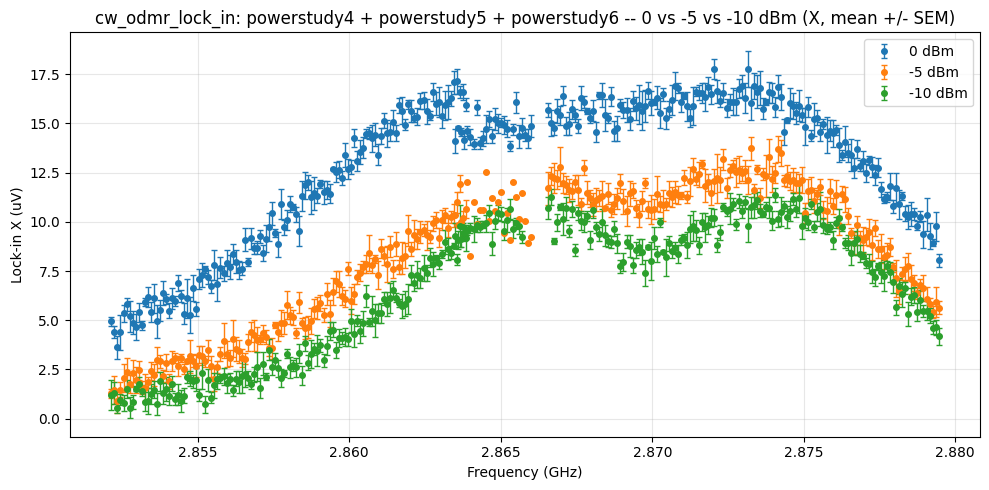

In [8]:
fig, ax = plt.subplots(figsize=(10, 5))

for label, d in power_stats_combined.items():
    ax.errorbar(d["freqs_ghz"], d["x_mean"] * 1e6, yerr=d["x_sem"] * 1e6,
                fmt="o", ms=4, capsize=2, lw=1, label=label)

ax.set_xlabel("Frequency (GHz)")
ax.set_ylabel("Lock-in X (uV)")
ax.set_title("cw_odmr_lock_in: powerstudy4 + powerstudy5 + powerstudy6 -- "
             "0 vs -5 vs -10 dBm (X, mean +/- SEM)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# cw_odmr_lock_in result: powerstudy8 + powerstudy9 -- all power levels

Combines `powerstudy8` (~2.8622-2.8773 GHz) and `powerstudy9` (~2.8513-2.8676 GHz) per power level -- the two segments partially overlap. Common power levels: 0, -5, -10, -15, -20 dBm (powerstudy8 also has -25 dBm, included on its own). Mean +/- SEM via `mean_sem_for_run()` (defined above), which already skips partial repeats.

In [9]:
RUNS_89 = [
    (r"D:\cw_odmr_lock_in\powerstudy8", "powerstudy8"),
    (r"D:\cw_odmr_lock_in\powerstudy9", "powerstudy9"),
]
POWER_TAGS_89 = {
    "0 dBm": "p0dBm",
    "-5 dBm": "pm5dBm",
    "-10 dBm": "pm10dBm",
    "-15 dBm": "pm15dBm",
    "-20 dBm": "pm20dBm",
    "-25 dBm": "pm25dBm",
}

power_stats_89 = {}
for label, tag in POWER_TAGS_89.items():
    freqs_list, mean_list, sem_list = [], [], []
    for run_path, prefix in RUNS_89:
        if not os.path.exists(f"{run_path}/{prefix}_{tag}_repeat0_x.npy"):
            continue
        freqs_hz, x_mean, x_sem, n = mean_sem_for_run(run_path, prefix, tag)
        freqs_list.append(freqs_hz)
        mean_list.append(x_mean)
        sem_list.append(x_sem)
        print(f"{label}: {prefix} contributes {len(freqs_hz)} points, {n} repeats")
    if not freqs_list:
        continue
    freqs_hz_all = np.concatenate(freqs_list)
    x_mean_all = np.concatenate(mean_list)
    x_sem_all = np.concatenate(sem_list)
    order = np.argsort(freqs_hz_all)
    power_stats_89[label] = dict(
        freqs_ghz=freqs_hz_all[order] / 1e9,
        x_mean=x_mean_all[order],
        x_sem=x_sem_all[order],
    )

0 dBm: powerstudy8 contributes 152 points, 25 repeats
-5 dBm: powerstudy8 contributes 152 points, 25 repeats
-10 dBm: powerstudy8 contributes 152 points, 25 repeats
-15 dBm: powerstudy8 contributes 152 points, 25 repeats
-20 dBm: powerstudy8 contributes 152 points, 25 repeats
-25 dBm: powerstudy8 contributes 152 points, 25 repeats


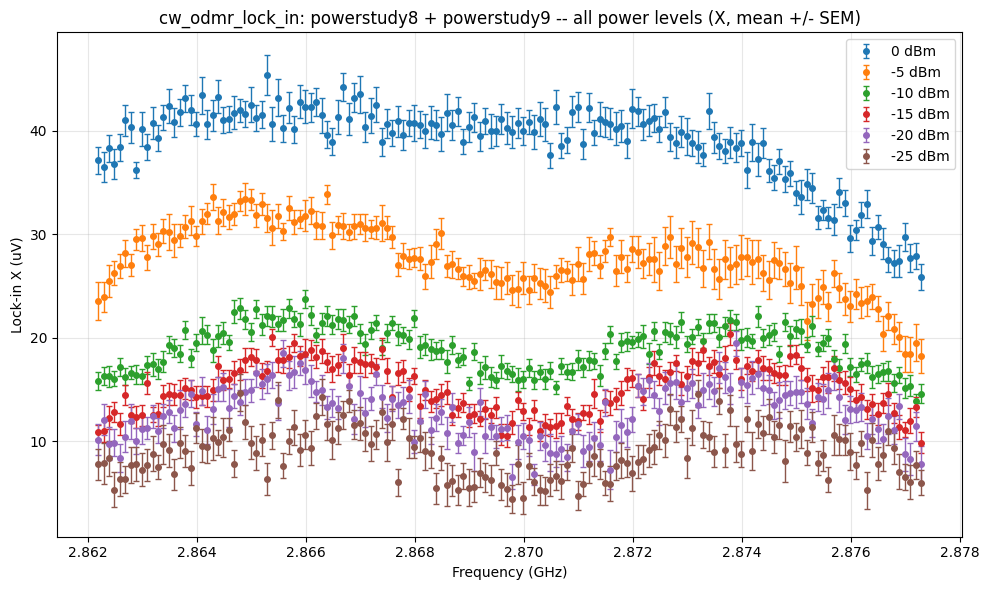

In [10]:
fig, ax = plt.subplots(figsize=(10, 6))

for label, d in power_stats_89.items():
    ax.errorbar(d["freqs_ghz"], d["x_mean"] * 1e6, yerr=d["x_sem"] * 1e6,
                fmt="o", ms=4, capsize=2, lw=1, label=label)

ax.set_xlabel("Frequency (GHz)")
ax.set_ylabel("Lock-in X (uV)")
ax.set_title("cw_odmr_lock_in: powerstudy8 + powerstudy9 -- "
             "all power levels (X, mean +/- SEM)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Double-Lorentzian fit, per power level (powerstudy8 + powerstudy9, no static field applied)

Same treatment as the `powerscan1-8` double-Lorentzian section below -- `powerstudy8` contributes 25 repeats per power level here (the most-averaged dataset in this notebook), so this is the least-noisy check of whether a second feature is resolvable without the static-field coil on.

In [11]:
from scipy.signal import find_peaks


def double_lorentzian_dip(f, baseline, amp1, center1, fwhm1, amp2, center2, fwhm2):
    return (baseline
            - amp1 * (fwhm1 / 2) ** 2 / ((f - center1) ** 2 + (fwhm1 / 2) ** 2)
            - amp2 * (fwhm2 / 2) ** 2 / ((f - center2) ** 2 + (fwhm2 / 2) ** 2))


double_fits_89 = {}
for label, d in power_stats_89.items():
    freqs_mhz = d["freqs_ghz"] * 1e3
    x_uv = d["x_mean"] * 1e6

    baseline_guess = np.median(np.concatenate([x_uv[:10], x_uv[-10:]]))
    deviation = np.abs(x_uv - baseline_guess)
    peak_idx, props = find_peaks(deviation, prominence=deviation.max() * 0.1, distance=5)
    if len(peak_idx) < 2:
        print(f"{label}: only found {len(peak_idx)} candidate peak(s), skipping")
        continue
    top2 = peak_idx[np.argsort(props["prominences"])[::-1][:2]]
    top2 = np.sort(top2)

    center1_guess = freqs_mhz[top2[0]]
    center2_guess = freqs_mhz[top2[1]]
    amp1_guess = baseline_guess - x_uv[top2[0]]
    amp2_guess = baseline_guess - x_uv[top2[1]]
    fwhm_guess = (freqs_mhz.max() - freqs_mhz.min()) / 10

    try:
        popt, pcov = curve_fit(
            double_lorentzian_dip, freqs_mhz, x_uv,
            p0=[baseline_guess, amp1_guess, center1_guess, fwhm_guess,
                amp2_guess, center2_guess, fwhm_guess],
            maxfev=50000,
        )
        perr = np.sqrt(np.diag(pcov))
        double_fits_89[label] = dict(popt=popt, perr=perr, freqs_mhz=freqs_mhz, x_uv=x_uv)
        (baseline_fit, amp1_fit, center1_fit, fwhm1_fit,
         amp2_fit, center2_fit, fwhm2_fit) = popt
        print(f"{label}: peak1 center={center1_fit:.4f}+/-{perr[2]:.4f} MHz, "
              f"FWHM={abs(fwhm1_fit):.4f} MHz; peak2 center={center2_fit:.4f}+/-"
              f"{perr[5]:.4f} MHz, FWHM={abs(fwhm2_fit):.4f} MHz; "
              f"separation={abs(center2_fit - center1_fit):.4f} MHz")
    except RuntimeError as e:
        print(f"{label}: fit failed ({e})")

0 dBm: peak1 center=2863.9428+/-0.4125 MHz, FWHM=12.7326 MHz; peak2 center=2873.1129+/-0.2916 MHz, FWHM=12.7966 MHz; separation=9.1701 MHz
-5 dBm: peak1 center=2864.6712+/-0.2157 MHz, FWHM=9.8694 MHz; peak2 center=2874.0367+/-0.2701 MHz, FWHM=10.6914 MHz; separation=9.3655 MHz
-10 dBm: peak1 center=2865.5862+/-0.1055 MHz, FWHM=7.1511 MHz; peak2 center=2874.1696+/-0.1140 MHz, FWHM=6.4636 MHz; separation=8.5835 MHz
-15 dBm: peak1 center=2865.7296+/-0.0860 MHz, FWHM=5.7716 MHz; peak2 center=2874.2142+/-0.0878 MHz, FWHM=5.4733 MHz; separation=8.4845 MHz
-20 dBm: peak1 center=2865.5442+/-0.1349 MHz, FWHM=6.1354 MHz; peak2 center=2874.2757+/-0.1290 MHz, FWHM=5.4490 MHz; separation=8.7315 MHz
-25 dBm: peak1 center=2865.6014+/-0.2002 MHz, FWHM=6.2379 MHz; peak2 center=2874.3690+/-0.1951 MHz, FWHM=5.5134 MHz; separation=8.7676 MHz


In [12]:
single_fits_89 = {}
for label, d in power_stats_89.items():
    freqs_mhz = d["freqs_ghz"] * 1e3
    x_uv = d["x_mean"] * 1e6

    baseline_guess = np.median(np.concatenate([x_uv[:10], x_uv[-10:]]))
    dip_idx = np.argmax(np.abs(x_uv - baseline_guess))
    center_guess = freqs_mhz[dip_idx]
    amp_guess = baseline_guess - x_uv[dip_idx]
    fwhm_guess = (freqs_mhz.max() - freqs_mhz.min()) / 10

    try:
        popt, pcov = curve_fit(
            lorentzian_dip, freqs_mhz, x_uv,
            p0=[baseline_guess, amp_guess, center_guess, fwhm_guess],
            maxfev=50000,
        )
        perr = np.sqrt(np.diag(pcov))
        single_fits_89[label] = dict(popt=popt, perr=perr, freqs_mhz=freqs_mhz, x_uv=x_uv)
        baseline_fit, amp_fit, center_fit, fwhm_fit = popt
        print(f"{label}: single-Lorentzian center={center_fit:.4f}+/-{perr[2]:.4f} MHz, "
              f"FWHM={abs(fwhm_fit):.4f} MHz")
    except RuntimeError as e:
        print(f"{label}: fit failed ({e})")

print()
print(f"{'label':>10s}  {'single RSS/dof':>16s}  {'double RSS/dof':>16s}")
for label in power_stats_89:
    if label not in single_fits_89 or label not in double_fits_89:
        continue
    sf, df = single_fits_89[label], double_fits_89[label]
    resid_single = sf["x_uv"] - lorentzian_dip(sf["freqs_mhz"], *sf["popt"])
    resid_double = df["x_uv"] - double_lorentzian_dip(df["freqs_mhz"], *df["popt"])
    rss_single = np.sum(resid_single ** 2) / (len(resid_single) - 4)
    rss_double = np.sum(resid_double ** 2) / (len(resid_double) - 7)
    print(f"{label:>10s}  {rss_single:16.4f}  {rss_double:16.4f}")


0 dBm: single-Lorentzian center=2867.5111+/-0.1701 MHz, FWHM=2183.8116 MHz
-5 dBm: single-Lorentzian center=2865.4011+/-0.1576 MHz, FWHM=5.0576 MHz
-10 dBm: single-Lorentzian center=2865.8625+/-0.1537 MHz, FWHM=2.2978 MHz
-15 dBm: single-Lorentzian center=2873.7840+/-0.1866 MHz, FWHM=1.5387 MHz
-20 dBm: single-Lorentzian center=2873.8730+/-0.1544 MHz, FWHM=1.3798 MHz
-25 dBm: single-Lorentzian center=2866.5428+/-0.1633 MHz, FWHM=1.3647 MHz

     label    single RSS/dof    double RSS/dof
     0 dBm            2.8534            1.5036
    -5 dBm            4.2159            1.2332
   -10 dBm            3.2006            0.8498
   -15 dBm            4.9381            1.1247
   -20 dBm            5.5408            2.3050
   -25 dBm            4.7815            3.0160


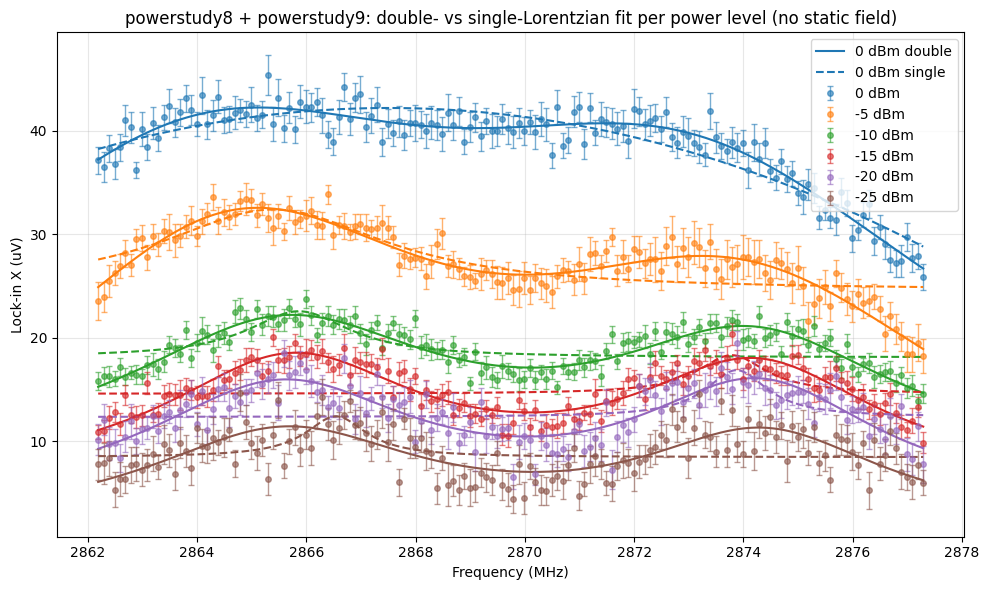

In [13]:
fig, ax = plt.subplots(figsize=(10, 6))

for i, (label, d) in enumerate(power_stats_89.items()):
    color = colors[i % len(colors)]
    ax.errorbar(d["freqs_ghz"] * 1e3, d["x_mean"] * 1e6, yerr=d["x_sem"] * 1e6,
                fmt="o", ms=4, capsize=2, lw=1, color=color, alpha=0.6, label=label)

    if label in double_fits_89:
        fr = double_fits_89[label]
        f_fine = np.linspace(fr["freqs_mhz"].min(), fr["freqs_mhz"].max(), 600)
        ax.plot(f_fine, double_lorentzian_dip(f_fine, *fr["popt"]), "-", color=color, lw=1.5,
                label=f"{label} double" if i == 0 else None)
    if label in single_fits_89:
        fr = single_fits_89[label]
        f_fine = np.linspace(fr["freqs_mhz"].min(), fr["freqs_mhz"].max(), 600)
        ax.plot(f_fine, lorentzian_dip(f_fine, *fr["popt"]), "--", color=color, lw=1.5,
                label=f"{label} single" if i == 0 else None)

ax.set_xlabel("Frequency (MHz)")
ax.set_ylabel("Lock-in X (uV)")
ax.set_title("powerstudy8 + powerstudy9: double- vs single-Lorentzian fit per power level (no static field)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# cw_odmr_lock_in result: powerscan1 - powerscan8 -- all power levels

Combines `powerscan1` (~2.8677-2.8812 GHz), `powerscan2` (~2.8445-2.8565 GHz), `powerscan3` (~2.8521-2.8657 GHz, slightly overlapping `powerscan2`), `powerscan4` (~2.865-2.870 GHz, overlapping `powerscan1`), `powerscan5` (~2.880-2.885 GHz), `powerscan6` (~2.884-2.890 GHz, adjacent to `powerscan5`), `powerscan7` (~2.889-2.893 GHz, adjacent to `powerscan6`), and `powerscan8` (~2.892-2.895 GHz, adjacent/overlapping `powerscan7`) per power level -- same convention as the `powerstudy` combination sections above (`mean_sem_for_run()`, segments concatenated and sorted by frequency). Common power levels: 0, -5, -10, -15, -20 dBm. Only 1 repeat per run/power level, so error bars are all-zero.

In [14]:
RUNS_POWERSCAN = [
    (r"D:\cw_odmr_lock_in\powerscan1", "powerscan1"),
    (r"D:\cw_odmr_lock_in\powerscan2", "powerscan2"),
    (r"D:\cw_odmr_lock_in\powerscan3", "powerscan3"),
    (r"D:\cw_odmr_lock_in\powerscan4", "powerscan4"),
    (r"D:\cw_odmr_lock_in\powerscan5", "powerscan5"),
    (r"D:\cw_odmr_lock_in\powerscan6", "powerscan6"),
    (r"D:\cw_odmr_lock_in\powerscan7", "powerscan7"),
    (r"D:\cw_odmr_lock_in\powerscan8", "powerscan8"),
]
POWER_TAGS_POWERSCAN = {
    "0 dBm": "p0dBm",
    "-5 dBm": "pm5dBm",
    "-10 dBm": "pm10dBm",
    "-15 dBm": "pm15dBm",
    "-20 dBm": "pm20dBm",
}

power_stats_powerscan = {}
for label, tag in POWER_TAGS_POWERSCAN.items():
    freqs_list, mean_list, sem_list = [], [], []
    for run_path, prefix in RUNS_POWERSCAN:
        if not os.path.exists(f"{run_path}/{prefix}_{tag}_repeat0_x.npy"):
            continue
        freqs_hz, x_mean, x_sem, n = mean_sem_for_run(run_path, prefix, tag)
        freqs_list.append(freqs_hz)
        mean_list.append(x_mean)
        sem_list.append(x_sem)
        print(f"{label}: {prefix} contributes {len(freqs_hz)} points, {n} repeats")
    if not freqs_list:
        continue
    freqs_hz_all = np.concatenate(freqs_list)
    x_mean_all = np.concatenate(mean_list)
    x_sem_all = np.concatenate(sem_list)
    order = np.argsort(freqs_hz_all)
    power_stats_powerscan[label] = dict(
        freqs_ghz=freqs_hz_all[order] / 1e9,
        x_mean=x_mean_all[order],
        x_sem=x_sem_all[order],
    )

0 dBm: powerscan1 contributes 136 points, 1 repeats
0 dBm: powerscan2 contributes 121 points, 1 repeats
0 dBm: powerscan3 contributes 137 points, 1 repeats
0 dBm: powerscan4 contributes 51 points, 1 repeats
0 dBm: powerscan5 contributes 51 points, 1 repeats
0 dBm: powerscan6 contributes 61 points, 1 repeats
0 dBm: powerscan7 contributes 41 points, 1 repeats
0 dBm: powerscan8 contributes 31 points, 1 repeats
-5 dBm: powerscan1 contributes 136 points, 1 repeats
-5 dBm: powerscan2 contributes 121 points, 1 repeats
-5 dBm: powerscan3 contributes 137 points, 1 repeats
-5 dBm: powerscan4 contributes 51 points, 1 repeats
-5 dBm: powerscan5 contributes 51 points, 1 repeats
-5 dBm: powerscan6 contributes 61 points, 1 repeats
-5 dBm: powerscan7 contributes 41 points, 1 repeats
-5 dBm: powerscan8 contributes 31 points, 1 repeats
-10 dBm: powerscan1 contributes 136 points, 1 repeats
-10 dBm: powerscan2 contributes 121 points, 1 repeats
-10 dBm: powerscan3 contributes 137 points, 1 repeats
-10 dBm:

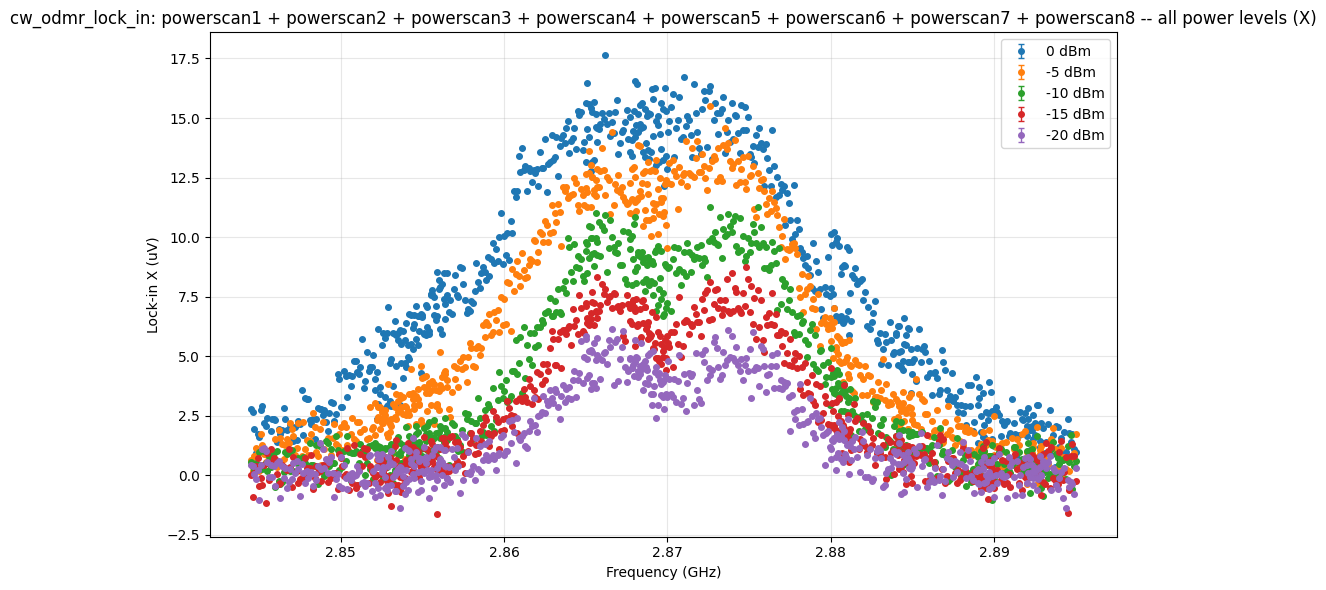

In [15]:
fig, ax = plt.subplots(figsize=(10, 6))

for label, d in power_stats_powerscan.items():
    ax.errorbar(d["freqs_ghz"], d["x_mean"] * 1e6, yerr=d["x_sem"] * 1e6,
                fmt="o", ms=4, capsize=2, lw=1, label=label)

ax.set_xlabel("Frequency (GHz)")
ax.set_ylabel("Lock-in X (uV)")
ax.set_title("cw_odmr_lock_in: " + " + ".join(prefix for _, prefix in RUNS_POWERSCAN) +
             " -- all power levels (X)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Double-Lorentzian fit, per power level (no static field applied)

These `powerscan*` runs were taken with the static-field coil off, so a single NV resonance dip is the naive expectation -- fitting two Lorentzians anyway to check whether a second feature is actually resolvable here too. Same `double_lorentzian_dip()` function and peak-finding approach as the `static_new` `power_up`/non-`power_up` sections above, applied independently to each power level's `x_mean` in `power_stats_powerscan`.

In [16]:
from scipy.signal import find_peaks


def double_lorentzian_dip(f, baseline, amp1, center1, fwhm1, amp2, center2, fwhm2):
    return (baseline
            - amp1 * (fwhm1 / 2) ** 2 / ((f - center1) ** 2 + (fwhm1 / 2) ** 2)
            - amp2 * (fwhm2 / 2) ** 2 / ((f - center2) ** 2 + (fwhm2 / 2) ** 2))


double_fits_powerscan = {}
for label, d in power_stats_powerscan.items():
    freqs_mhz = d["freqs_ghz"] * 1e3
    x_uv = d["x_mean"] * 1e6

    baseline_guess = np.median(np.concatenate([x_uv[:10], x_uv[-10:]]))
    deviation = np.abs(x_uv - baseline_guess)
    peak_idx, props = find_peaks(deviation, prominence=deviation.max() * 0.1, distance=5)
    if len(peak_idx) < 2:
        print(f"{label}: only found {len(peak_idx)} candidate peak(s), skipping")
        continue
    top2 = peak_idx[np.argsort(props["prominences"])[::-1][:2]]
    top2 = np.sort(top2)

    center1_guess = freqs_mhz[top2[0]]
    center2_guess = freqs_mhz[top2[1]]
    amp1_guess = baseline_guess - x_uv[top2[0]]
    amp2_guess = baseline_guess - x_uv[top2[1]]
    fwhm_guess = (freqs_mhz.max() - freqs_mhz.min()) / 10

    try:
        popt, pcov = curve_fit(
            double_lorentzian_dip, freqs_mhz, x_uv,
            p0=[baseline_guess, amp1_guess, center1_guess, fwhm_guess,
                amp2_guess, center2_guess, fwhm_guess],
            maxfev=50000,
        )
        perr = np.sqrt(np.diag(pcov))
        double_fits_powerscan[label] = dict(popt=popt, perr=perr, freqs_mhz=freqs_mhz, x_uv=x_uv)
        (baseline_fit, amp1_fit, center1_fit, fwhm1_fit,
         amp2_fit, center2_fit, fwhm2_fit) = popt
        print(f"{label}: peak1 center={center1_fit:.4f}+/-{perr[2]:.4f} MHz, "
              f"FWHM={abs(fwhm1_fit):.4f} MHz; peak2 center={center2_fit:.4f}+/-"
              f"{perr[5]:.4f} MHz, FWHM={abs(fwhm2_fit):.4f} MHz; "
              f"separation={abs(center2_fit - center1_fit):.4f} MHz")
    except RuntimeError as e:
        print(f"{label}: fit failed ({e})")

0 dBm: peak1 center=2864.0448+/-0.3186 MHz, FWHM=17.1649 MHz; peak2 center=2874.1911+/-0.2808 MHz, FWHM=15.6657 MHz; separation=10.1463 MHz
-5 dBm: peak1 center=2864.7769+/-0.1192 MHz, FWHM=12.4555 MHz; peak2 center=2874.2391+/-0.0938 MHz, FWHM=10.5766 MHz; separation=9.4622 MHz
-10 dBm: peak1 center=2865.6479+/-0.0753 MHz, FWHM=8.9397 MHz; peak2 center=2874.6305+/-0.0760 MHz, FWHM=8.7943 MHz; separation=8.9826 MHz
-15 dBm: peak1 center=2865.6914+/-0.0825 MHz, FWHM=8.0795 MHz; peak2 center=2874.5502+/-0.0877 MHz, FWHM=8.3410 MHz; separation=8.8588 MHz
-20 dBm: peak1 center=2866.1327+/-0.1009 MHz, FWHM=7.5022 MHz; peak2 center=2874.6747+/-0.1180 MHz, FWHM=7.5179 MHz; separation=8.5419 MHz


In [17]:
single_fits_powerscan = {}
for label, d in power_stats_powerscan.items():
    freqs_mhz = d["freqs_ghz"] * 1e3
    x_uv = d["x_mean"] * 1e6

    baseline_guess = np.median(np.concatenate([x_uv[:10], x_uv[-10:]]))
    dip_idx = np.argmax(np.abs(x_uv - baseline_guess))
    center_guess = freqs_mhz[dip_idx]
    amp_guess = baseline_guess - x_uv[dip_idx]
    fwhm_guess = (freqs_mhz.max() - freqs_mhz.min()) / 10

    try:
        popt, pcov = curve_fit(
            lorentzian_dip, freqs_mhz, x_uv,
            p0=[baseline_guess, amp_guess, center_guess, fwhm_guess],
            maxfev=50000,
        )
        perr = np.sqrt(np.diag(pcov))
        single_fits_powerscan[label] = dict(popt=popt, perr=perr, freqs_mhz=freqs_mhz, x_uv=x_uv)
        baseline_fit, amp_fit, center_fit, fwhm_fit = popt
        print(f"{label}: single-Lorentzian center={center_fit:.4f}+/-{perr[2]:.4f} MHz, "
              f"FWHM={abs(fwhm_fit):.4f} MHz")
    except RuntimeError as e:
        print(f"{label}: fit failed ({e})")

print()
print(f"{'label':>10s}  {'single RSS/dof':>16s}  {'double RSS/dof':>16s}")
for label in power_stats_powerscan:
    if label not in single_fits_powerscan or label not in double_fits_powerscan:
        continue
    sf, df = single_fits_powerscan[label], double_fits_powerscan[label]
    resid_single = sf["x_uv"] - lorentzian_dip(sf["freqs_mhz"], *sf["popt"])
    resid_double = df["x_uv"] - double_lorentzian_dip(df["freqs_mhz"], *df["popt"])
    rss_single = np.sum(resid_single ** 2) / (len(resid_single) - 4)
    rss_double = np.sum(resid_double ** 2) / (len(resid_double) - 7)
    print(f"{label:>10s}  {rss_single:16.4f}  {rss_double:16.4f}")


0 dBm: single-Lorentzian center=2869.0585+/-0.0672 MHz, FWHM=30.2039 MHz
-5 dBm: single-Lorentzian center=2869.6558+/-0.0731 MHz, FWHM=24.6260 MHz
-10 dBm: single-Lorentzian center=2870.2916+/-0.0943 MHz, FWHM=21.5909 MHz
-15 dBm: single-Lorentzian center=2870.3104+/-0.1106 MHz, FWHM=21.0746 MHz
-20 dBm: single-Lorentzian center=2870.2729+/-0.1357 MHz, FWHM=19.7793 MHz

     label    single RSS/dof    double RSS/dof
     0 dBm            1.0201            0.8478
    -5 dBm            1.0623            0.4257
   -10 dBm            1.1660            0.3855
   -15 dBm            0.8834            0.3533
   -20 dBm            0.6225            0.3525


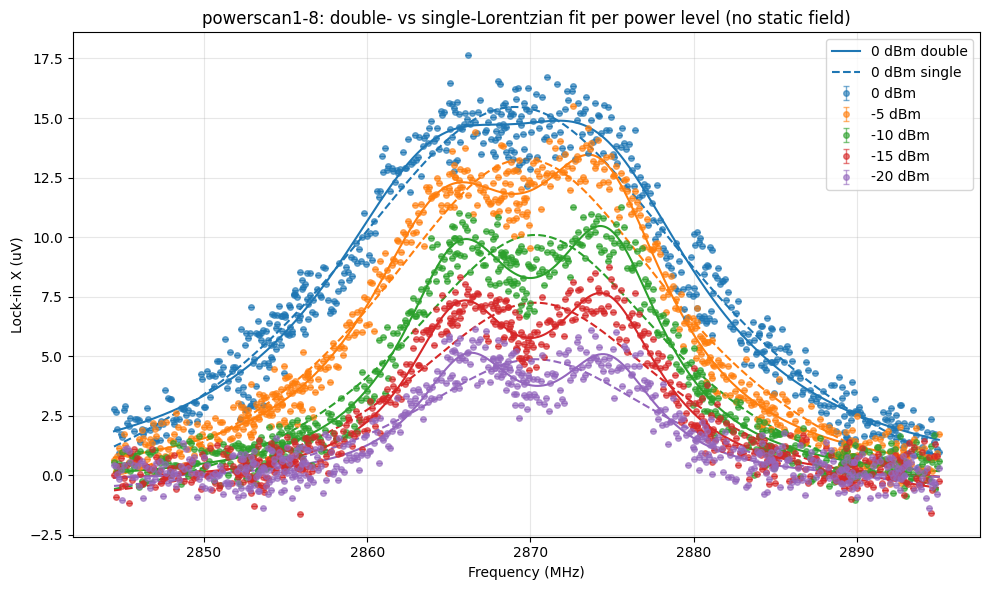

In [18]:
fig, ax = plt.subplots(figsize=(10, 6))

for i, (label, d) in enumerate(power_stats_powerscan.items()):
    color = colors[i % len(colors)]
    ax.errorbar(d["freqs_ghz"] * 1e3, d["x_mean"] * 1e6, yerr=d["x_sem"] * 1e6,
                fmt="o", ms=4, capsize=2, lw=1, color=color, alpha=0.6, label=label)

    if label in double_fits_powerscan:
        fr = double_fits_powerscan[label]
        f_fine = np.linspace(fr["freqs_mhz"].min(), fr["freqs_mhz"].max(), 600)
        ax.plot(f_fine, double_lorentzian_dip(f_fine, *fr["popt"]), "-", color=color, lw=1.5,
                label=f"{label} double" if i == 0 else None)
    if label in single_fits_powerscan:
        fr = single_fits_powerscan[label]
        f_fine = np.linspace(fr["freqs_mhz"].min(), fr["freqs_mhz"].max(), 600)
        ax.plot(f_fine, lorentzian_dip(f_fine, *fr["popt"]), "--", color=color, lw=1.5,
                label=f"{label} single" if i == 0 else None)

ax.set_xlabel("Frequency (MHz)")
ax.set_ylabel("Lock-in X (uV)")
ax.set_title("powerscan1-8: double- vs single-Lorentzian fit per power level (no static field)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# Static field, 1.5 A, ~dist from diamond, 0 dBm drive

`run`-style single-sweep results (same `_lockin_spectrum_*` file layout as `scan1-scan8` above) from `D:\cw_odmr_lock_in\static{1..5}` -- taken with the static-field coil (SPD1168X) on. Plotted on their own, both X and R.

In [19]:
STATIC_RUN_NAMES = ["static1", "static2", "static3", "static4", "static5"]

static_runs = {}
for name in STATIC_RUN_NAMES:
    run_path = f"{DATA_DIR}/{name}"
    freqs_hz = np.load(f"{run_path}/{name}_lockin_spectrum_freqs_hz.npy")
    x = np.load(f"{run_path}/{name}_lockin_spectrum_x.npy")
    y = np.load(f"{run_path}/{name}_lockin_spectrum_y.npy")
    static_runs[name] = dict(freqs_ghz=freqs_hz / 1e9, x=x, r=np.hypot(x, y))
    print(f"{name}: {len(freqs_hz)} points, "
          f"{freqs_hz.min()/1e9:.6f}-{freqs_hz.max()/1e9:.6f} GHz")

static1: 156 points, 2.827750-2.843250 GHz
static2: 138 points, 2.905500-2.919200 GHz
static3: 126 points, 2.838600-2.851100 GHz
static4: 142 points, 2.850175-2.864275 GHz
static5: 121 points, 2.864125-2.876125 GHz


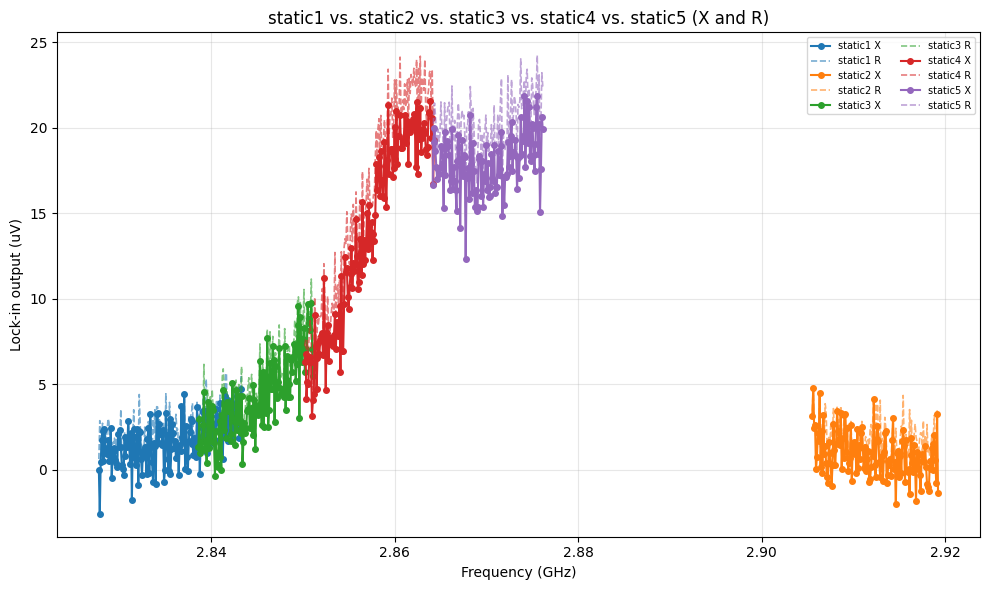

In [20]:
fig, ax = plt.subplots(figsize=(10, 6))

for i, name in enumerate(STATIC_RUN_NAMES):
    d = static_runs[name]
    color = colors[i % len(colors)]
    ax.plot(d["freqs_ghz"], d["x"] * 1e6, "o-", color=color, ms=4, label=f"{name} X")
    ax.plot(d["freqs_ghz"], d["r"] * 1e6, "--", color=color, lw=1.2, alpha=0.6, label=f"{name} R")

ax.set_xlabel("Frequency (GHz)")
ax.set_ylabel("Lock-in output (uV)")
ax.set_title(" vs. ".join(STATIC_RUN_NAMES) + " (X and R)")
ax.legend(fontsize=7, ncol=2)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# cw_odmr_lock_in result: static_new1-16 and their power_up runs (X and R)

Same `run`-style single-sweep layout as the static field runs above, from `D:\cw_odmr_lock_in\static_new{1,3,4,5,7,8,9,12,13,14}` and `static_new{1,2,3,6,7,8,9,10,11,12,13,14,15,16}_power_up` (there is no plain `static_new2`, `static_new6`, `static_new10`, `static_new11`, or `static_new16`). Plotted separately from the set above, both X and R.

`static_new15_power_up`'s folder was renamed after the fact (it was originally saved as `static_new15`, without the `_power_up` suffix, despite actually having been run at the power-up/0 dBm condition) -- the files inside it still carry the old `static_new15_*` prefix, so it's loaded with an explicit `(folder, file_prefix)` pair below instead of assuming they match.

In [21]:
STATIC_NEW_RUN_NAMES = [
    "static_new1", "static_new1_power_up",
    "static_new2_power_up",
    "static_new3", "static_new3_power_up",
    "static_new4",
    "static_new5",
    "static_new6_power_up",
    "static_new7", "static_new7_power_up",
    "static_new8", "static_new8_power_up",
    "static_new9", "static_new9_power_up",
    "static_new10_power_up",
    "static_new11_power_up",
    "static_new12", "static_new12_power_up",
    "static_new13", "static_new13_power_up",
    "static_new14", "static_new14_power_up",
    "static_new15_power_up",
    "static_new16_power_up",
]

# (folder, file_prefix) -- normally identical, except static_new15_power_up
# whose folder was renamed after the fact (originally saved as
# "static_new15", without the "_power_up" suffix, despite actually having
# been run at the power-up/0 dBm condition) -- the files inside still
# carry the old "static_new15_*" prefix.
STATIC_NEW_FILE_PREFIX = {
    "static_new15_power_up": "static_new15",
}

static_new_runs = {}
for name in STATIC_NEW_RUN_NAMES:
    prefix = STATIC_NEW_FILE_PREFIX.get(name, name)
    run_path = f"{DATA_DIR}/{name}"
    freqs_hz = np.load(f"{run_path}/{prefix}_lockin_spectrum_freqs_hz.npy")
    x = np.load(f"{run_path}/{prefix}_lockin_spectrum_x.npy")
    y = np.load(f"{run_path}/{prefix}_lockin_spectrum_y.npy")
    static_new_runs[name] = dict(freqs_ghz=freqs_hz / 1e9, x=x, r=np.hypot(x, y))
    print(f"{name}: {len(freqs_hz)} points, "
          f"{freqs_hz.min()/1e9:.6f}-{freqs_hz.max()/1e9:.6f} GHz")

static_new1: 127 points, 2.867025-2.879625 GHz
static_new1_power_up: 130 points, 2.866875-2.879775 GHz
static_new2_power_up: 137 points, 2.853325-2.866925 GHz
static_new3: 131 points, 2.845725-2.858725 GHz
static_new3_power_up: 125 points, 2.845125-2.857525 GHz
static_new4: 145 points, 2.798750-2.813150 GHz
static_new5: 142 points, 2.814400-2.828500 GHz
static_new6_power_up: 122 points, 2.930925-2.943025 GHz
static_new7: 114 points, 2.879600-2.890900 GHz
static_new7_power_up: 114 points, 2.879350-2.890650 GHz
static_new8: 121 points, 2.885875-2.897875 GHz
static_new8_power_up: 121 points, 2.885575-2.897575 GHz
static_new9: 126 points, 2.895600-2.908100 GHz
static_new9_power_up: 126 points, 2.895475-2.907975 GHz
static_new10_power_up: 123 points, 2.935075-2.947275 GHz
static_new11_power_up: 122 points, 2.897425-2.909525 GHz
static_new12: 101 points, 2.910000-2.920000 GHz
static_new12_power_up: 89 points, 2.910000-2.918800 GHz
static_new13: 146 points, 2.835400-2.849900 GHz
static_new13_

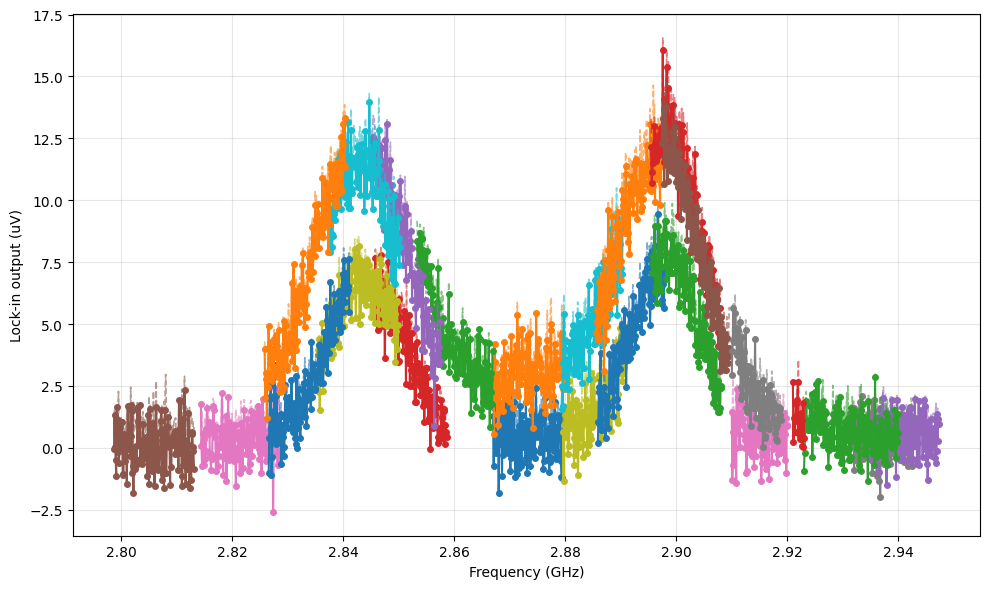

In [22]:
fig, ax = plt.subplots(figsize=(10, 6))

for i, name in enumerate(STATIC_NEW_RUN_NAMES):
    d = static_new_runs[name]
    color = colors[i % len(colors)]
    ax.plot(d["freqs_ghz"], d["x"] * 1e6, "o-", color=color, ms=4, label=f"{name} X")
    ax.plot(d["freqs_ghz"], d["r"] * 1e6, "--", color=color, lw=1.2, alpha=0.6, label=f"{name} R")

ax.set_xlabel("Frequency (GHz)")
ax.set_ylabel("Lock-in output (uV)")
# ax.set_title(" vs. ".join(STATIC_NEW_RUN_NAMES) + " (X and R)")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## power_up runs only, X

Just the `*_power_up` subset of `STATIC_NEW_RUN_NAMES` above, plotted on its own.

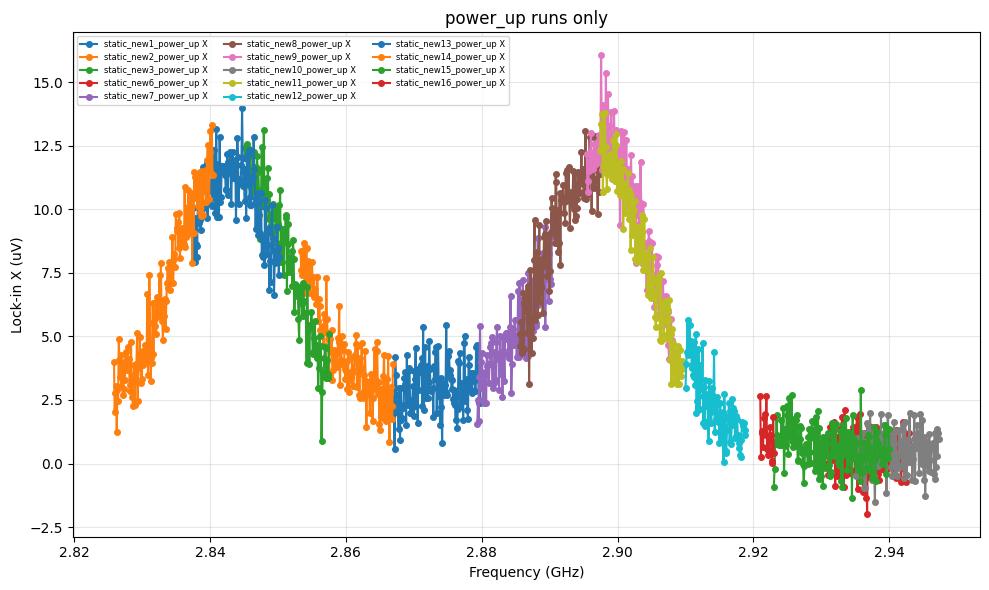

In [23]:
POWER_UP_RUN_NAMES = [n for n in STATIC_NEW_RUN_NAMES if n.endswith("_power_up")]

fig, ax = plt.subplots(figsize=(10, 6))

for i, name in enumerate(POWER_UP_RUN_NAMES):
    d = static_new_runs[name]
    color = colors[i % len(colors)]
    ax.plot(d["freqs_ghz"], d["x"] * 1e6, "o-", color=color, ms=4, label=f"{name} X")

ax.set_xlabel("Frequency (GHz)")
ax.set_ylabel("Lock-in X (uV)")
ax.set_title("power_up runs only")
ax.legend(fontsize=6, ncol=3)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Double-Lorentzian fit to the combined power_up data

Pools every point from all `POWER_UP_RUN_NAMES` (sorted by frequency, same convention as the earlier "Combined fit" section) and fits a SUM of two Lorentzian dips instead of one, since the power_up plot above shows two separate features. Initial peak-center guesses are found automatically via `scipy.signal.find_peaks` on the deviation from baseline, picking the two most prominent.

In [24]:
from scipy.signal import find_peaks


def double_lorentzian_dip(f, baseline, amp1, center1, fwhm1, amp2, center2, fwhm2):
    return (baseline
            - amp1 * (fwhm1 / 2) ** 2 / ((f - center1) ** 2 + (fwhm1 / 2) ** 2)
            - amp2 * (fwhm2 / 2) ** 2 / ((f - center2) ** 2 + (fwhm2 / 2) ** 2))


combined_freqs_mhz_pu = np.concatenate(
    [static_new_runs[n]["freqs_ghz"] * 1e3 for n in POWER_UP_RUN_NAMES])
combined_x_uv_pu = np.concatenate(
    [static_new_runs[n]["x"] * 1e6 for n in POWER_UP_RUN_NAMES])

order = np.argsort(combined_freqs_mhz_pu)
combined_freqs_mhz_pu = combined_freqs_mhz_pu[order]
combined_x_uv_pu = combined_x_uv_pu[order]

print(f"{len(combined_freqs_mhz_pu)} combined points, "
      f"{combined_freqs_mhz_pu.min():.4f}-{combined_freqs_mhz_pu.max():.4f} MHz")

baseline_guess_pu = np.median(np.concatenate([combined_x_uv_pu[:10], combined_x_uv_pu[-10:]]))
deviation_pu = np.abs(combined_x_uv_pu - baseline_guess_pu)
peak_idx, props = find_peaks(deviation_pu, prominence=deviation_pu.max() * 0.1, distance=5)
if len(peak_idx) < 2:
    raise RuntimeError(f"only found {len(peak_idx)} candidate peak(s) -- lower the "
                        f"prominence threshold above")
top2 = peak_idx[np.argsort(props["prominences"])[::-1][:2]]
top2 = np.sort(top2)  # order by frequency, so center1 < center2

center1_guess = combined_freqs_mhz_pu[top2[0]]
center2_guess = combined_freqs_mhz_pu[top2[1]]
amp1_guess = baseline_guess_pu - combined_x_uv_pu[top2[0]]
amp2_guess = baseline_guess_pu - combined_x_uv_pu[top2[1]]
fwhm_guess_pu = (combined_freqs_mhz_pu.max() - combined_freqs_mhz_pu.min()) / 30

double_popt, double_pcov = curve_fit(
    double_lorentzian_dip, combined_freqs_mhz_pu, combined_x_uv_pu,
    p0=[baseline_guess_pu, amp1_guess, center1_guess, fwhm_guess_pu,
        amp2_guess, center2_guess, fwhm_guess_pu],
    maxfev=50000,
)
double_perr = np.sqrt(np.diag(double_pcov))
# order: [baseline, amp1, center1, fwhm1, amp2, center2, fwhm2]
(baseline_fit_pu, amp1_fit, center1_fit, fwhm1_fit,
 amp2_fit, center2_fit, fwhm2_fit) = double_popt

print(f"baseline = {baseline_fit_pu:.4f} +/- {double_perr[0]:.4f} uV")
print(f"peak 1: center = {center1_fit:.4f} +/- {double_perr[2]:.4f} MHz, "
      f"amplitude = {amp1_fit:.4f} +/- {double_perr[1]:.4f} uV, "
      f"FWHM = {abs(fwhm1_fit):.4f} +/- {double_perr[3]:.4f} MHz")
print(f"peak 2: center = {center2_fit:.4f} +/- {double_perr[5]:.4f} MHz, "
      f"amplitude = {amp2_fit:.4f} +/- {double_perr[4]:.4f} uV, "
      f"FWHM = {abs(fwhm2_fit):.4f} +/- {double_perr[6]:.4f} MHz")
print(f"peak separation = {abs(center2_fit - center1_fit):.4f} MHz")

1677 combined points, 2825.8750-2947.2750 MHz
baseline = -0.4759 +/- 0.0591 uV
peak 1: center = 2843.0800 +/- 0.0840 MHz, amplitude = -12.0294 +/- 0.0985 uV, FWHM = 22.4979 +/- 0.3317 MHz
peak 2: center = 2897.1984 +/- 0.0677 MHz, amplitude = -12.5457 +/- 0.0916 uV, FWHM = 18.7929 +/- 0.2691 MHz
peak separation = 54.1184 MHz


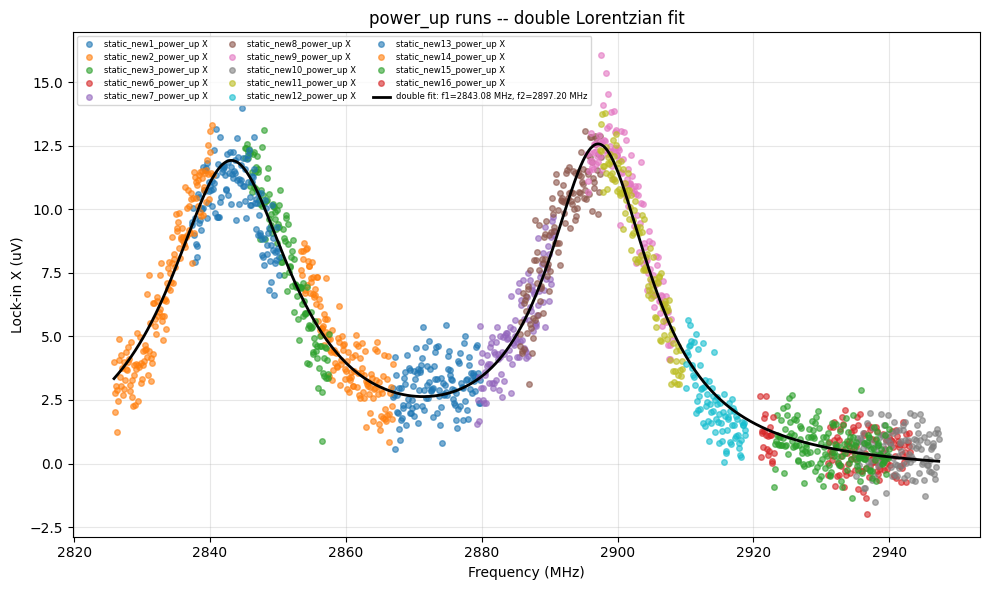

In [25]:
fig, ax = plt.subplots(figsize=(10, 6))

for i, name in enumerate(POWER_UP_RUN_NAMES):
    d = static_new_runs[name]
    color = colors[i % len(colors)]
    ax.plot(d["freqs_ghz"] * 1e3, d["x"] * 1e6, "o", color=color, ms=4, alpha=0.6,
            label=f"{name} X")

f_fine_pu = np.linspace(combined_freqs_mhz_pu.min(), combined_freqs_mhz_pu.max(), 2000)
ax.plot(f_fine_pu, double_lorentzian_dip(f_fine_pu, *double_popt), "k-", lw=2,
        label=f"double fit: f1={center1_fit:.2f} MHz, f2={center2_fit:.2f} MHz")

ax.set_xlabel("Frequency (MHz)")
ax.set_ylabel("Lock-in X (uV)")
ax.set_title("power_up runs -- double Lorentzian fit")
ax.legend(fontsize=6, ncol=3)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Non-power_up runs only, X, with double-Lorentzian fit

Same treatment as the `power_up` section above, but for the complementary subset -- `STATIC_NEW_RUN_NAMES` entries that do NOT end in `_power_up`.

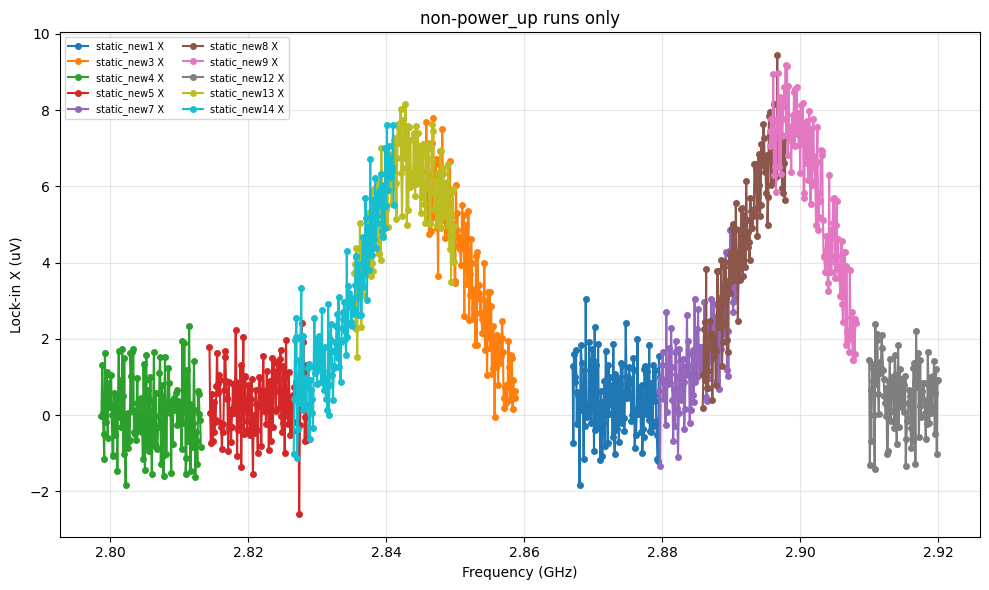

In [26]:
NON_POWER_UP_RUN_NAMES = [n for n in STATIC_NEW_RUN_NAMES if not n.endswith("_power_up")]

fig, ax = plt.subplots(figsize=(10, 6))

for i, name in enumerate(NON_POWER_UP_RUN_NAMES):
    d = static_new_runs[name]
    color = colors[i % len(colors)]
    ax.plot(d["freqs_ghz"], d["x"] * 1e6, "o-", color=color, ms=4, label=f"{name} X")

ax.set_xlabel("Frequency (GHz)")
ax.set_ylabel("Lock-in X (uV)")
ax.set_title("non-power_up runs only")
ax.legend(fontsize=7, ncol=2)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [27]:
combined_freqs_mhz_npu = np.concatenate(
    [static_new_runs[n]["freqs_ghz"] * 1e3 for n in NON_POWER_UP_RUN_NAMES])
combined_x_uv_npu = np.concatenate(
    [static_new_runs[n]["x"] * 1e6 for n in NON_POWER_UP_RUN_NAMES])

order = np.argsort(combined_freqs_mhz_npu)
combined_freqs_mhz_npu = combined_freqs_mhz_npu[order]
combined_x_uv_npu = combined_x_uv_npu[order]

print(f"{len(combined_freqs_mhz_npu)} combined points, "
      f"{combined_freqs_mhz_npu.min():.4f}-{combined_freqs_mhz_npu.max():.4f} MHz")

baseline_guess_npu = np.median(np.concatenate([combined_x_uv_npu[:10], combined_x_uv_npu[-10:]]))
deviation_npu = np.abs(combined_x_uv_npu - baseline_guess_npu)
peak_idx_npu, props_npu = find_peaks(deviation_npu, prominence=deviation_npu.max() * 0.1,
                                       distance=5)
if len(peak_idx_npu) < 2:
    raise RuntimeError(f"only found {len(peak_idx_npu)} candidate peak(s) -- lower the "
                        f"prominence threshold above")
top2_npu = peak_idx_npu[np.argsort(props_npu["prominences"])[::-1][:2]]
top2_npu = np.sort(top2_npu)  # order by frequency, so center1 < center2

center1_guess_npu = combined_freqs_mhz_npu[top2_npu[0]]
center2_guess_npu = combined_freqs_mhz_npu[top2_npu[1]]
amp1_guess_npu = baseline_guess_npu - combined_x_uv_npu[top2_npu[0]]
amp2_guess_npu = baseline_guess_npu - combined_x_uv_npu[top2_npu[1]]
fwhm_guess_npu = (combined_freqs_mhz_npu.max() - combined_freqs_mhz_npu.min()) / 30

double_popt_npu, double_pcov_npu = curve_fit(
    double_lorentzian_dip, combined_freqs_mhz_npu, combined_x_uv_npu,
    p0=[baseline_guess_npu, amp1_guess_npu, center1_guess_npu, fwhm_guess_npu,
        amp2_guess_npu, center2_guess_npu, fwhm_guess_npu],
    maxfev=50000,
)
double_perr_npu = np.sqrt(np.diag(double_pcov_npu))
# order: [baseline, amp1, center1, fwhm1, amp2, center2, fwhm2]
(baseline_fit_npu, amp1_fit_npu, center1_fit_npu, fwhm1_fit_npu,
 amp2_fit_npu, center2_fit_npu, fwhm2_fit_npu) = double_popt_npu

print(f"baseline = {baseline_fit_npu:.4f} +/- {double_perr_npu[0]:.4f} uV")
print(f"peak 1: center = {center1_fit_npu:.4f} +/- {double_perr_npu[2]:.4f} MHz, "
      f"amplitude = {amp1_fit_npu:.4f} +/- {double_perr_npu[1]:.4f} uV, "
      f"FWHM = {abs(fwhm1_fit_npu):.4f} +/- {double_perr_npu[3]:.4f} MHz")
print(f"peak 2: center = {center2_fit_npu:.4f} +/- {double_perr_npu[5]:.4f} MHz, "
      f"amplitude = {amp2_fit_npu:.4f} +/- {double_perr_npu[4]:.4f} uV, "
      f"FWHM = {abs(fwhm2_fit_npu):.4f} +/- {double_perr_npu[6]:.4f} MHz")
print(f"peak separation = {abs(center2_fit_npu - center1_fit_npu):.4f} MHz")

1299 combined points, 2798.7500-2920.0000 MHz
baseline = -0.6789 +/- 0.0646 uV
peak 1: center = 2843.8312 +/- 0.0979 MHz, amplitude = -7.6413 +/- 0.1030 uV, FWHM = 16.5765 +/- 0.4569 MHz
peak 2: center = 2898.1917 +/- 0.0961 MHz, amplitude = -8.4420 +/- 0.1120 uV, FWHM = 14.2285 +/- 0.3331 MHz
peak separation = 54.3605 MHz


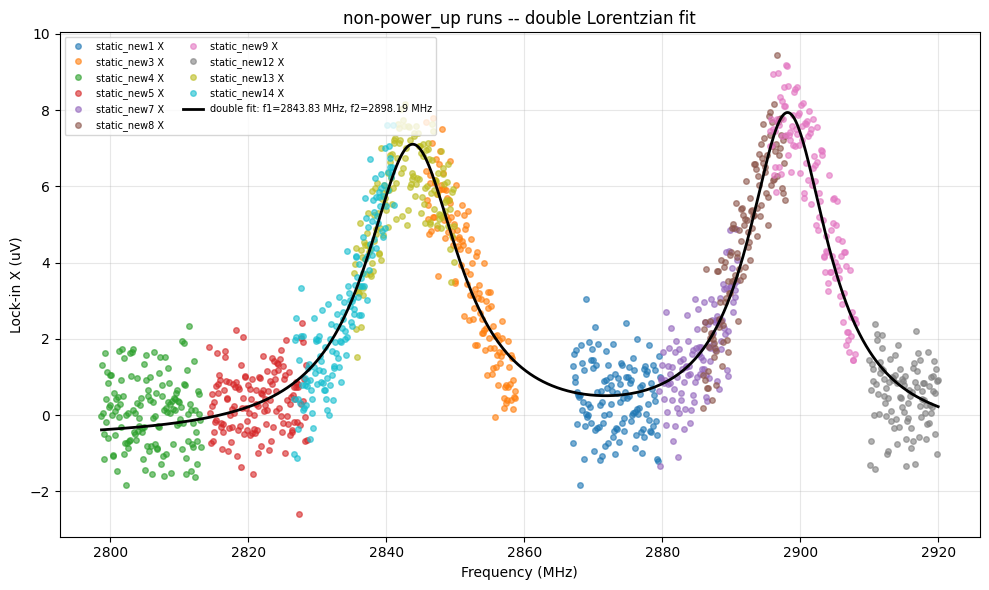

In [28]:
fig, ax = plt.subplots(figsize=(10, 6))

for i, name in enumerate(NON_POWER_UP_RUN_NAMES):
    d = static_new_runs[name]
    color = colors[i % len(colors)]
    ax.plot(d["freqs_ghz"] * 1e3, d["x"] * 1e6, "o", color=color, ms=4, alpha=0.6,
            label=f"{name} X")

f_fine_npu = np.linspace(combined_freqs_mhz_npu.min(), combined_freqs_mhz_npu.max(), 2000)
ax.plot(f_fine_npu, double_lorentzian_dip(f_fine_npu, *double_popt_npu), "k-", lw=2,
        label=f"double fit: f1={center1_fit_npu:.2f} MHz, f2={center2_fit_npu:.2f} MHz")

ax.set_xlabel("Frequency (MHz)")
ax.set_ylabel("Lock-in X (uV)")
ax.set_title("non-power_up runs -- double Lorentzian fit")
ax.legend(fontsize=7, ncol=2)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()